# 02 FE-IV Baseline Results
## FE-IV 기준 결과

가격 내생성을 고려하기 위해 `log_price`를 `log_cost`로 도구화한 FE-IV 결과를 정리한다.
핵심 질문은 가격 상승이 자기 상품 판매량을 얼마나 낮추는지이다.


## Setup
### 설정


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables" / "model_results"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

CATEGORY_LABELS = {
    "cereal": "Cereal",
    "canned_soup": "Canned soup",
    "bottled_juices": "Bottled juices",
    "cookies": "Cookies",
}


In [2]:
def read_csv(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def category_from_path(path):
    name = Path(path).name
    for category in CATEGORY_LABELS:
        if name.startswith(category):
            return category
    return None


def load_category_files(suffix):
    frames = []
    for path in sorted(TABLE_DIR.glob(f"*_only/*_{suffix}.csv")):
        frame = read_csv(path)
        if "category" not in frame.columns:
            frame["category"] = category_from_path(path)
        frames.append(frame)
    if not frames:
        raise FileNotFoundError(f"No files matched suffix: {suffix}")
    return pd.concat(frames, ignore_index=True)


def add_category_label(frame):
    out = frame.copy()
    out["category_label"] = out["category"].map(CATEGORY_LABELS).fillna(out["category"])
    return out


def save_figure(name):
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    return path


## Own-price elasticity
### 자기 상품 가격 탄력성

카테고리별 기준 specification의 own-sales 계수를 비교한다.


In [3]:
ladder = load_category_files("fe_iv_own_sales_control_ladder")
ladder = add_category_label(ladder)

baseline = (
    ladder[(ladder["outcome_name"] == "own_sales") & (ladder["spec"].isin(["A_none", "B_ccount_only", "C_plus_deal"]))]
    .sort_values(["category_label", "spec"])
)

display(
    baseline[[
        "category_label", "spec", "coef_log_price", "std_error", "t_stat",
        "p_value", "n_obs", "n_store_upc_clusters", "first_stage_t"
    ]]
)


,category_label,spec,coef_log_price,std_error,t_stat,p_value,n_obs,n_store_upc_clusters,first_stage_t
0,Bottled juices,A_none,-0.213192,0.108438,-1.966035,4.929458e-02,6113366,36386,24.980051
5,Bottled juices,A_none,-0.213192,0.185289,-1.150592,2.499000e-01,6113366,36386,19.553738
1,Bottled juices,B_ccount_only,-0.189112,0.111633,-1.694045,9.025680e-02,5963789,36386,25.053541
6,Bottled juices,B_ccount_only,-0.189112,0.190217,-0.994189,3.201309e-01,5963789,36386,19.393685
2,Bottled juices,C_plus_deal,0.410118,0.100863,4.066082,4.781021e-05,5963789,36386,25.838802
7,Canned soup,A_none,-0.224371,0.036106,-6.214199,5.158716e-10,6862202,32693,93.499566
12,Canned soup,A_none,-0.224371,0.138732,-1.617298,1.058141e-01,6862202,32693,24.644890
8,Canned soup,B_ccount_only,-0.284672,0.035025,-8.127737,4.440892e-16,6704250,32692,92.236738
13,Canned soup,B_ccount_only,-0.284672,0.136166,-2.090630,3.656122e-02,6704250,32692,24.087396
9,Canned soup,C_plus_deal,0.390610,0.032950,11.854618,0.000000e+00,6704250,32692,82.894557


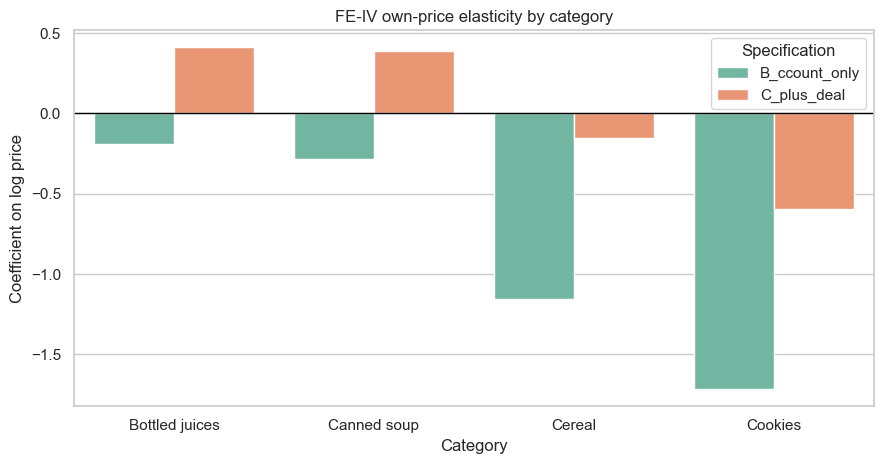

C:\Users\박동하\Documents\Codex\2026-05-16\files-mentioned-by-the-user-untitled48\dominicks-price-elasticity-iv-dml\outputs\figures\fe_iv_own_price_elasticity.png


In [4]:
plot_data = baseline[baseline["spec"].isin(["B_ccount_only", "C_plus_deal"])].copy()
plt.figure(figsize=(9, 4.8))
sns.barplot(data=plot_data, x="category_label", y="coef_log_price", hue="spec", palette="Set2")
plt.axhline(0, color="black", linewidth=1)
plt.title("FE-IV own-price elasticity by category")
plt.xlabel("Category")
plt.ylabel("Coefficient on log price")
plt.legend(title="Specification")
path = save_figure("fe_iv_own_price_elasticity.png")
plt.show()
print(path)


대부분의 기준 specification에서 가격 계수는 음수다.
다만 deal 변수를 포함하면 일부 카테고리의 계수가 크게 이동해, 가격 효과와 판촉 변수가 강하게 얽혀 있음을 보여준다.


## First-stage strength
### 1단계 도구변수 강도

도구변수 `log_cost`가 가격 변동을 충분히 설명하는지 first-stage t-stat을 확인한다.


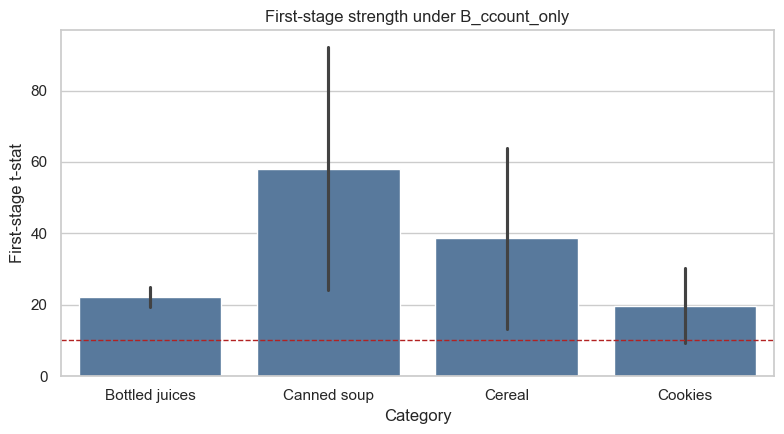

C:\Users\박동하\Documents\Codex\2026-05-16\files-mentioned-by-the-user-untitled48\dominicks-price-elasticity-iv-dml\outputs\figures\fe_iv_first_stage_strength.png


,category_label,first_stage_coef,first_stage_t,first_stage_t2
1,Bottled juices,0.182941,25.053541,627.679903
6,Bottled juices,0.182941,19.393685,376.115016
8,Canned soup,0.535262,92.236738,8507.615790
13,Canned soup,0.535262,24.087396,580.202656
15,Cereal,0.425842,64.005632,4096.720916
20,Cereal,0.425842,13.197182,174.165613
22,Cookies,0.110997,30.191327,911.516230
27,Cookies,0.110997,9.291221,86.326790


In [5]:
first_stage = baseline[baseline["spec"] == "B_ccount_only"].copy()
plt.figure(figsize=(8, 4.5))
sns.barplot(data=first_stage, x="category_label", y="first_stage_t", color="#4C78A8")
plt.axhline(10, color="firebrick", linestyle="--", linewidth=1)
plt.title("First-stage strength under B_ccount_only")
plt.xlabel("Category")
plt.ylabel("First-stage t-stat")
path = save_figure("fe_iv_first_stage_strength.png")
plt.show()
print(path)

display(first_stage[["category_label", "first_stage_coef", "first_stage_t", "first_stage_t2"]])


모든 카테고리에서 first-stage t-stat은 통상적 기준을 크게 넘는다.
따라서 이 결과표만 보면 비용 기반 도구변수는 약한 도구변수 문제보다는 해석 가능성과 exclusion restriction 검토가 더 중요하다.


## Sales decomposition
### 판매 반응 분해

가격 변화가 자기 상품, 같은 제조사, 경쟁 제조사, 카테고리 전체 판매량에 어떻게 나타나는지 비교한다.


,category_label,outcome_name,coef_log_price,std_error,t_stat,n_obs
16,Bottled juices,category_total_sales,0.002110,0.005989,0.352324,5963789
21,Bottled juices,own_pseudo_logit,0.125245,0.140863,0.889124,5963789
6,Bottled juices,rival_mfr_sales,0.028764,0.007288,3.946840,5963789
11,Bottled juices,same_com_code_sales,0.025241,0.006063,4.162994,5963789
1,Bottled juices,same_mfr_sales,0.203670,0.043465,4.685837,5963789
41,Canned soup,category_total_sales,-0.002518,0.003962,-0.635574,6704250
46,Canned soup,own_pseudo_logit,0.011362,0.042125,0.269728,6704250
31,Canned soup,rival_mfr_sales,0.263977,0.006275,42.066015,6704250
36,Canned soup,same_com_code_sales,-0.183646,0.007512,-24.445767,6704250
26,Canned soup,same_mfr_sales,0.106230,0.030451,3.488581,6704250


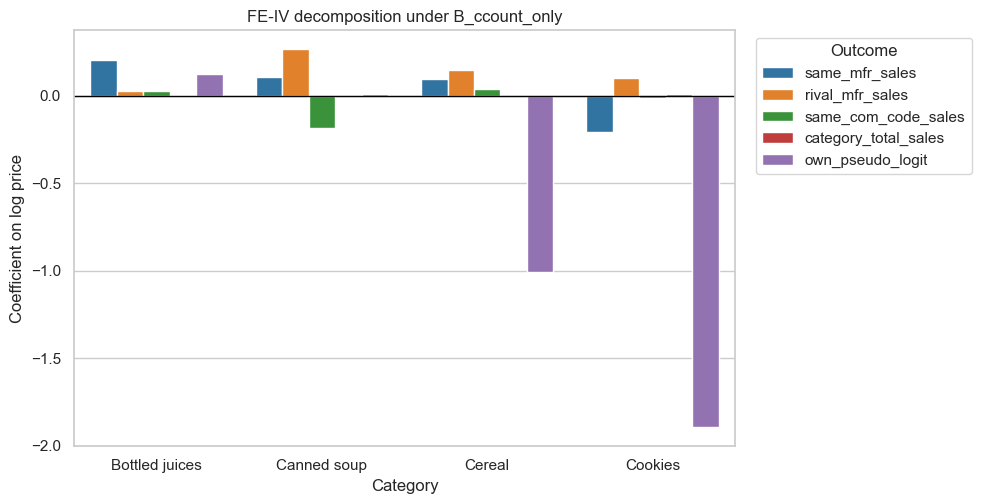

C:\Users\박동하\Documents\Codex\2026-05-16\files-mentioned-by-the-user-untitled48\dominicks-price-elasticity-iv-dml\outputs\figures\fe_iv_sales_decomposition.png


In [6]:
decomp = load_category_files("fe_iv_decomposition_results")
decomp = add_category_label(decomp)
decomp_b = decomp[decomp["spec"] == "B_ccount_only"].copy()

display(
    decomp_b[["category_label", "outcome_name", "coef_log_price", "std_error", "t_stat", "n_obs"]]
    .sort_values(["category_label", "outcome_name"])
)

plt.figure(figsize=(10, 5.2))
sns.barplot(data=decomp_b, x="category_label", y="coef_log_price", hue="outcome_name", palette="tab10")
plt.axhline(0, color="black", linewidth=1)
plt.title("FE-IV decomposition under B_ccount_only")
plt.xlabel("Category")
plt.ylabel("Coefficient on log price")
plt.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
path = save_figure("fe_iv_sales_decomposition.png")
plt.show()
print(path)


own-sales 반응은 대체로 음수지만, same/rival/category 결과는 카테고리마다 다르게 움직인다.
즉 가격 탄력성은 단일 계수보다 제품군 내 대체 구조와 함께 해석해야 한다.
